## Setup

Loading the feature-engineered AirPassengers dataset, `pmdarima`'s `auto_arima` for automatic order selection, and our evaluation metrics.

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error, r2_score

In [ ]:
df= joblib.load(r"C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl")

In [ ]:
df.head()

,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [ ]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    144 non-null    int64  
 1   month          144 non-null    int32  
 2   quarter        144 non-null    int32  
 3   lag1           143 non-null    float64
 4   lag2           142 non-null    float64
 5   lag3           141 non-null    float64
 6   rolling_mean3  142 non-null    float64
 7   rolling_std3   142 non-null    float64
 8   rolling_mean6  139 non-null    float64
 9   rolling_std6   139 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 11.2 KB
None


,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
count,144.000000,144.000000,144.000000,143.000000,142.000000,141.000000,142.000000,142.000000,139.000000,139.000000
mean,280.298611,6.500000,2.500000,279.237762,278.457746,277.163121,280.500000,24.125941,280.151079,34.415635
std,119.966317,3.464102,1.121936,119.708270,119.766772,119.192439,116.940083,17.180862,111.943814,20.641465
min,104.000000,1.000000,1.000000,104.000000,104.000000,104.000000,112.333333,1.154701,119.666667,8.916277
25%,180.000000,3.750000,1.750000,180.000000,180.000000,180.000000,184.916667,12.013857,182.416667,18.978871
50%,265.500000,6.500000,2.500000,264.000000,264.000000,264.000000,261.666667,20.219624,259.166667,26.515404
75%,360.500000,9.250000,3.250000,359.500000,358.250000,356.000000,357.666667,31.873737,362.416667,46.286518
max,622.000000,12.000000,4.000000,622.000000,622.000000,622.000000,587.666667,76.872188,534.000000,94.200672


In [ ]:
df = df[['#Passengers','month','quarter']]

# Non-leaky exogenous features: cyclical encodings of calendar position.
# These only depend on the date itself (never on target history), so
# they can be computed identically for train, test, and any future period.
df['month_sin']   = np.sin(2*np.pi*df.index.month/12)
df['month_cos']   = np.cos(2*np.pi*df.index.month/12)
df['quarter_sin'] = np.sin(2*np.pi*df.index.quarter/4)
df['quarter_cos'] = np.cos(2*np.pi*df.index.quarter/4)

df = df.drop(columns=['month','quarter'])

df.head()


,#Passengers,month_sin,month_cos,quarter_sin,quarter_cos
Month,,,,,
1949-01-01,112,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
1949-02-01,118,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
1949-03-01,132,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
1949-04-01,129,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
1949-05-01,121,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


## Index integrity and missing values

Confirming frequency and no duplicates, then backfilling the handful of NaNs at the start of the lag/rolling columns.

In [ ]:
print(df.index.freq)
print(df.index.dtype)
print(df.shape)
print(df.isnull().sum())
print(df.index.duplicated().sum())
df.bfill(inplace=True)
print(df.isnull().sum())
print(df.shape)

<MonthBegin>
datetime64[ns]
(144, 5)
#Passengers    0
month_sin      0
month_cos      0
quarter_sin    0
quarter_cos    0
dtype: int64
0
#Passengers    0
month_sin      0
month_cos      0
quarter_sin    0
quarter_cos    0
dtype: int64
(144, 5)


In [ ]:
train = df.iloc[:-12, :].copy()
test  = df.iloc[-12:, :].copy()

# Log-transform ONLY the target (multiplicative seasonality / stabilizing variance).
# Exogenous cyclical features are left in their natural [-1, 1] range —
# taking log() of them would be undefined for negative values.
train['#Passengers'] = np.log(train['#Passengers'])


In [ ]:
print(train.index.freq)
print(train.index.dtype)
print(train.shape)
print(train.isnull().sum())
print(train.index.duplicated().sum())

<MonthBegin>
datetime64[ns]
(132, 5)
#Passengers    0
month_sin      0
month_cos      0
quarter_sin    0
quarter_cos    0
dtype: int64
0


In [ ]:
test.shape

(12, 5)

In [ ]:
test.tail()

,#Passengers,month_sin,month_cos,quarter_sin,quarter_cos
Month,,,,,
1960-08-01,606,-8.660254e-01,-5.000000e-01,-1.000000e+00,-1.836970e-16
1960-09-01,508,-1.000000e+00,-1.836970e-16,-1.000000e+00,-1.836970e-16
1960-10-01,461,-8.660254e-01,5.000000e-01,-2.449294e-16,1.000000e+00
1960-11-01,390,-5.000000e-01,8.660254e-01,-2.449294e-16,1.000000e+00
1960-12-01,432,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00


In [ ]:
train.head()

,#Passengers,month_sin,month_cos,quarter_sin,quarter_cos
Month,,,,,
1949-01-01,4.718499,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
1949-02-01,4.770685,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
1949-03-01,4.882802,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
1949-04-01,4.859812,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
1949-05-01,4.795791,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


# ARIMA

Stationarity was checked explicitly in `main.ipynb` (ADF  before and after differencing)the test agreed  the raw series is non-stationary and a first difference is needed, consistent with the `d=1` that `auto_arima` selects below on its own via its internal stationarity search.

In [ ]:
arima= auto_arima(
  train['#Passengers'],
  seasonal=False
)

In [ ]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(1, 1, 5)   Log Likelihood                 138.569
Date:                Wed, 02 Sep 2026   AIC                           -261.138
Time:                        10:05:02   BIC                           -238.137
Sample:                    01-01-1949   HQIC                          -251.792
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0045      0.002      2.787      0.005       0.001       0.008
ar.L1          0.5542      0.138      4.004      0.000       0.283       0.826
ma.L1         -0.5912      0.102     -5.794      0.000      -0.791      -0.391
ma.L2         -0.2635      0.079     -3.330      0.001      -0.419      -0.108
ma.L3         -0.3491      0.090     -3.878      0.000      -0.526      -0.173
ma.L4         -0.3937      0.092     -4.290      0.000      -0.574      -0.214
ma.L5          0.7382      0.091      8.115      0.000       0.560       0.916
sigma2         0.0068      0.001      6.514      0.000       0.005       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 3.47
Prob(Q):                              0.75   Prob(JB):                         0.18
Heteroskedasticity (H):               1.11   Skew:                             0.35
Prob(H) (two-sided):                  0.73   Kurtosis:                         2.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
arima_forecast= arima.predict(len(test))
arima_forecast= np.exp(arima_forecast)
arima_forecast

1960-01-01    441.824891
1960-02-01    443.182662
1960-03-01    463.493181
1960-04-01    463.470023
1960-05-01    471.230129
1960-06-01    477.752563
1960-07-01    483.598527
1960-08-01    489.086400
1960-09-01    494.395901
1960-10-01    499.628271
1960-11-01    504.840549
1960-12-01    510.064945
Freq: MS, dtype: float64

In [ ]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions) , 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

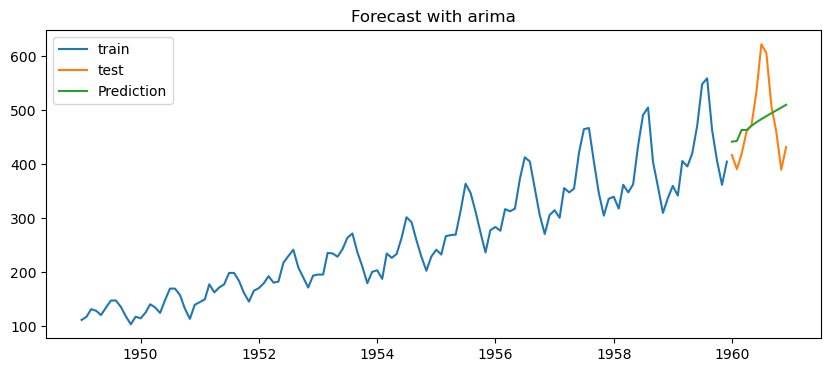

mean absolute error: 56.87
mean absolute percentage error: 12.0%
r2 score: 0.06
root mean squared error: 72.1


,mae,mape,r2,rmse
0,56.87,12.0,0.06,72.1


In [ ]:
model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],arima_forecast, 'arima')

# Sarima

In [ ]:
sarima= auto_arima(train['#Passengers'],
                   seasonal=True,
                   m=12)

In [ ]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  132
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 229.026
Date:                              Wed, 02 Sep 2026   AIC                           -448.052
Time:                                      10:07:11   BIC                           -434.114
Sample:                                  01-01-1949   HQIC                          -442.392
                                       - 12-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0193      0.009      2.159      0.031       0.002       0.037
ar.L1          0.6005      0.083      7.277      0.000       0.439       0.762
ar.L2          0.2412      0.085      2.847      0.004       0.075       0.407
ma.S.L12      -0.5672      0.105     -5.419      0.000      -0.772      -0.362
sigma2         0.0012      0.000      8.194      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.10
Prob(Q):                              1.00   Prob(JB):                         0.05
Heteroskedasticity (H):               0.36   Skew:                             0.07
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
sarima_forecast= sarima.predict(len(test))
sarima_forecast= np.exp(sarima_forecast)
sarima_forecast

1960-01-01    421.610357
1960-02-01    402.052863
1960-03-01    470.789693
1960-04-01    459.103790
1960-05-01    478.530593
1960-06-01    553.776403
1960-07-01    630.177169
1960-08-01    638.564443
1960-09-01    534.326715
1960-10-01    469.188365
1960-11-01    412.874467
1960-12-01    459.488309
Freq: MS, dtype: float64

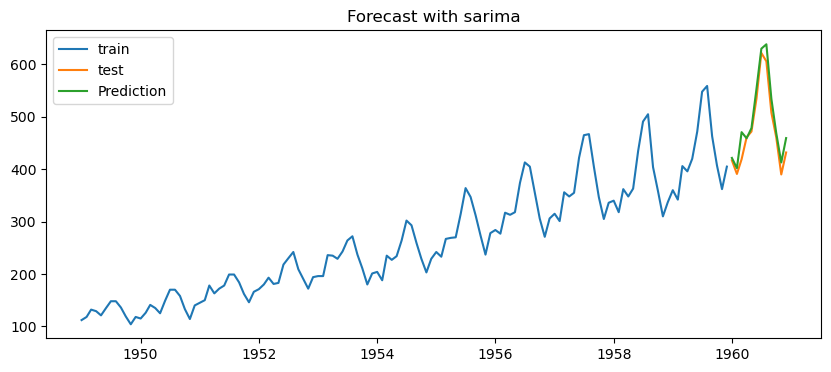

mean absolute error: 18.36
mean absolute percentage error: 4.0%
r2 score: 0.9
root mean squared error: 23.08


,mae,mape,r2,rmse
0,18.36,4.0,0.9,23.08


In [ ]:
model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],sarima_forecast, 'sarima')

# Sarimax

In [46]:
exog_train = train.drop(columns='#Passengers')
exog_test  = test.drop(columns='#Passengers')
exog_train.head()


,month_sin,month_cos,quarter_sin,quarter_cos
Month,,,,
1949-01-01,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
1949-02-01,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
1949-03-01,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
1949-04-01,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
1949-05-01,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


In [ ]:
sarimax= auto_arima(train['#Passengers'],
                    X= exog_train,
                    m=12,
                    seasonal=True,
                    )

In [ ]:
sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 236.315
Date:                            Wed, 02 Sep 2026   AIC                           -456.629
Time:                                    10:09:35   BIC                           -433.628
Sample:                                01-01-1949   HQIC                          -447.283
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
month_sin      -0.0064      0.097     -0.065      0.948      -0.197       0.184
month_cos      -0.1623      0.121     -1.345      0.179      -0.399       0.074
quarter_sin    -0.0274      0.071     -0.387      0.699      -0.166       0.111
quarter_cos     0.0462      0.101      0.459      0.647      -0.151       0.244
ma.L1          -0.3467      0.083     -4.172      0.000      -0.510      -0.184
ar.S.L12        0.9829      0.013     75.809      0.000       0.957       1.008
ma.S.L12       -0.5573      0.100     -5.580      0.000      -0.753      -0.362
sigma2          0.0013      0.000      8.487      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.35
Prob(Q):                              0.76   Prob(JB):                         0.84
Heteroskedasticity (H):               0.42   Skew:                             0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
sarimax_forecast = sarimax.predict(len(test), X=exog_test)
sarimax_forecast = np.exp(sarimax_forecast)
sarimax_forecast


1960-01-01    417.313216
1960-02-01    398.586330
1960-03-01    464.842527
1960-04-01    454.282104
1960-05-01    473.649510
1960-06-01    544.975716
1960-07-01    618.135989
1960-08-01    624.429870
1960-09-01    523.774162
1960-10-01    460.898222
1960-11-01    406.474259
1960-12-01    449.782457
Freq: MS, dtype: float64

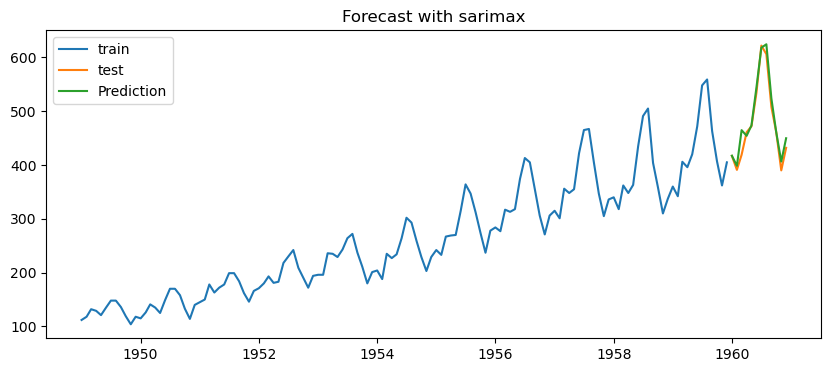

mean absolute error: 12.04
mean absolute percentage error: 3.0%
r2 score: 0.95
root mean squared error: 17.07


,mae,mape,r2,rmse
0,12.04,3.0,0.95,17.07


In [ ]:
model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],sarimax_forecast, 'sarimax')

In [ ]:
# Fine tunning 


fine_tuned_model = auto_arima(
    train['#Passengers'],
    X=exog_train,
    m=12,
    seasonal=True,
    start_P=0, max_P=5,
    start_q=0, max_q=5,
    start_p=0, max_p=5,
    start_Q=0, max_Q=5,
    maxiter=1000,
    stepwise=True,
    trace=True,
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore'
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-252.567, Time=0.26 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-428.805, Time=1.14 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-332.871, Time=1.11 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-253.067, Time=0.45 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-250.665, Time=1.20 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=7.57 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=-453.584, Time=5.42 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=-331.334, Time=0.98 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=-451.604, Time=19.17 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=-445.123, Time=5.49 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=-366.038, Time=3.63 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=-449.948, Time=11.44 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-443.656, Time=1.27 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=-450.942, Time=3.43 sec
 ARIMA(1,1,1)(1,0,1)[1

In [ ]:
fine_tuned_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 236.315
Date:                            Wed, 02 Sep 2026   AIC                           -456.629
Time:                                    10:12:33   BIC                           -433.628
Sample:                                01-01-1949   HQIC                          -447.283
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
month_sin      -0.0064      0.097     -0.065      0.948      -0.197       0.184
month_cos      -0.1623      0.121     -1.345      0.179      -0.399       0.074
quarter_sin    -0.0274      0.071     -0.387      0.699      -0.166       0.111
quarter_cos     0.0462      0.101      0.459      0.647      -0.151       0.244
ma.L1          -0.3467      0.083     -4.172      0.000      -0.510      -0.184
ar.S.L12        0.9829      0.013     75.809      0.000       0.957       1.008
ma.S.L12       -0.5573      0.100     -5.580      0.000      -0.753      -0.362
sigma2          0.0013      0.000      8.487      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.35
Prob(Q):                              0.76   Prob(JB):                         0.84
Heteroskedasticity (H):               0.42   Skew:                             0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
fine_tuned_model.get_params()

{'maxiter': 1000,
 'method': 'lbfgs',
 'order': (0, 1, 1),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (1, 0, 1, 12),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': False}

In [ ]:
forecast = fine_tuned_model.predict(n_periods=len(test), X=exog_test)
forecast = np.exp(forecast)
forecast


1960-01-01    417.313216
1960-02-01    398.586330
1960-03-01    464.842527
1960-04-01    454.282104
1960-05-01    473.649510
1960-06-01    544.975716
1960-07-01    618.135989
1960-08-01    624.429870
1960-09-01    523.774162
1960-10-01    460.898222
1960-11-01    406.474259
1960-12-01    449.782457
Freq: MS, dtype: float64

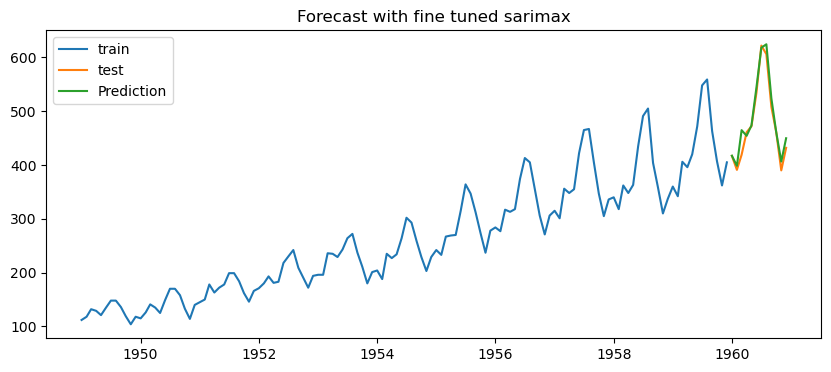

mean absolute error: 12.04
mean absolute percentage error: 3.0%
r2 score: 0.95
root mean squared error: 17.07


In [ ]:
sarimax_metric=model_evaluator(np.exp(train['#Passengers']), test['#Passengers'],forecast, 'fine tuned sarimax')

In [ ]:
sarimax_metric.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\sarimax_metric.csv')

In [ ]:
df1 = df.copy()
df1['#Passengers'] = np.log(df1['#Passengers'])
df_exog = df1.drop(columns='#Passengers')
df1.head()


,#Passengers,month_sin,month_cos,quarter_sin,quarter_cos
Month,,,,,
1949-01-01,4.718499,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
1949-02-01,4.770685,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
1949-03-01,4.882802,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
1949-04-01,4.859812,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
1949-05-01,4.795791,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


In [ ]:
# Future prediction model
# "The final model order was selected based on the lowest AIC obtained during the fine-tuning search."

final_model= ARIMA(order=fine_tuned_model.order,
                    seasonal_order=fine_tuned_model.seasonal_order,
                    maxiter=2000,
                    suppress_warnings=True)


In [ ]:
final_model.fit(y=df1['#Passengers'], X=df_exog)

ARIMA(maxiter=2000, order=(0, 1, 1), seasonal_order=(1, 0, 1, 12),
      suppress_warnings=True)

In [ ]:
final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 257.982
Date:                            Wed, 02 Sep 2026   AIC                           -497.964
Time:                                    10:12:43   BIC                           -471.299
Sample:                                01-01-1949   HQIC                          -487.129
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.0002      0.000      0.519      0.604      -0.000       0.001
month_sin      -0.0111      0.102     -0.108      0.914      -0.211       0.189
month_cos      -0.1529      0.118     -1.299      0.194      -0.383       0.078
quarter_sin    -0.0327      0.068     -0.483      0.629      -0.165       0.100
quarter_cos     0.0357      0.103      0.346      0.729      -0.166       0.238
ma.L1          -0.4052      0.076     -5.332      0.000      -0.554      -0.256
ar.S.L12        0.9799      0.014     68.748      0.000       0.952       1.008
ma.S.L12       -0.5446      0.103     -5.267      0.000      -0.747      -0.342
sigma2          0.0013      0.000      8.918      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                 0.66
Prob(Q):                              0.63   Prob(JB):                         0.72
Heteroskedasticity (H):               0.61   Skew:                             0.01
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
last_date= df.index[-1]
last_date

Timestamp('1960-12-01 00:00:00')

In [ ]:
period= 12

future_dates= pd.date_range(
  start=last_date + pd.DateOffset(months=1),
  periods=period ,
  freq='MS'
)

In [ ]:
future_dates

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [ ]:
future_data= pd.DataFrame(index=future_dates)

In [ ]:
def build_future_exog(future_dates):
    
    return pd.DataFrame({
        "month_sin":   np.sin(2*np.pi*future_dates.month/12),
        "month_cos":   np.cos(2*np.pi*future_dates.month/12),
        "quarter_sin": np.sin(2*np.pi*future_dates.quarter/4),
        "quarter_cos": np.cos(2*np.pi*future_dates.quarter/4),
    }, index=future_dates)


In [ ]:
future_exog = build_future_exog(future_dates)

forecast = final_model.predict(n_periods=len(future_dates), X=future_exog)


In [ ]:
future_exog.head()


,month_sin,month_cos,quarter_sin,quarter_cos
1961-01-01,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
1961-02-01,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
1961-03-01,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
1961-04-01,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
1961-05-01,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


In [ ]:
forecast = np.exp(forecast)
forecast


1961-01-01    448.242930
1961-02-01    425.684344
1961-03-01    477.791923
1961-04-01    493.056855
1961-05-01    510.596491
1961-06-01    582.280973
1961-07-01    666.879052
1961-08-01    662.657386
1961-09-01    556.987189
1961-10-01    497.436716
1961-11-01    431.692528
1961-12-01    476.606261
Freq: MS, dtype: float64

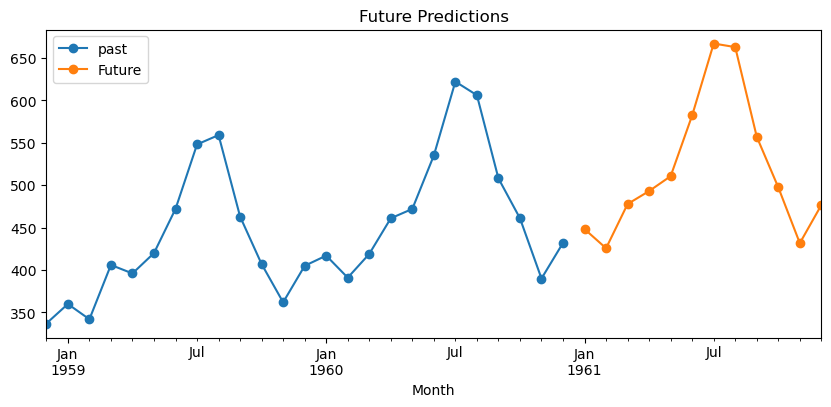

In [ ]:
plt.figure(figsize=(10,4))
df['#Passengers'].iloc[-25:].plot(label='past',marker='o')
forecast.plot(label='Future', marker='o')

plt.legend()
plt.title('Future Predictions')
plt.show()

In [ ]:
joblib.dump(final_model, r"C:\Users\MINE\Desktop\Air passenger prediction\models\sarimax.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\sarimax.pkl']